#**Text classification**

we are using **text** data which is unstructutre to analy spam and not spam

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import nltk
nltk.download("punkt")        # puntuation
nltk.download('punkt_tab')    # punkt_tab
nltk.download("stopwords")    # stopwords
nltk.download("wordnet")      # lemmatization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# load data of spam.csv and hold in dataframe
# utf-8 uniform text format --> "latin1"
df = pd.read_csv("/content/drive/MyDrive/Study/AI/Raw Data/spam.csv", encoding='latin1')

In [ ]:
# to show 1st - 5 records
df.head()

,category,Message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,not spam,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,not spam,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,not spam,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,not spam,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Problem Statement: To predict given message either sapm mail or  not a spam mail
- Target varibale : category
  - we have two category : Spam and Not Spam
- Input variable : Message

Given dataset is binary classifier becz we have 2 classes

In [ ]:
# How many samples of spam and not spam in given dataset
df["category"].value_counts()

,count
category,
not spam,4825
spam,747


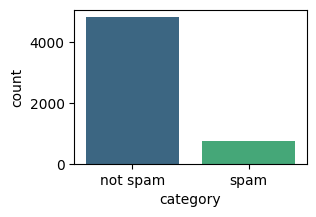

In [ ]:
# Visualisation
plt.figure(figsize=(3,2))
sns.countplot(data=df,x="category",palette="viridis")
plt.show()

In [ ]:
# how columns and rows
df.shape

(5572, 5)

In [ ]:
df.columns

Index(['category', 'Message', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [ ]:
# To check null records in given DataFrame
df.isna().sum()

,0
category,0
Message,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [ ]:
# To remove unwanted column permanently from given dataset
a = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
df.drop(a,axis=1,inplace=True)

In [ ]:
df.head()

,category,Message
0,not spam,"Go until jurong point, crazy.. Available only ..."
1,not spam,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,not spam,U dun say so early hor... U c already then say...
4,not spam,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# To show messages of spam category of given dataframe
df[df["category"] == "spam"]["Message"]

,Message
2,Free entry in 2 a wkly comp to win FA Cup fina...
5,FreeMsg Hey there darling it's been 3 week's n...
8,WINNER!! As a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...
11,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...
5537,Want explicit SEX in 30 secs? Ring 02073162414...
5540,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,Had your contract mobile 11 Mnths? Latest Moto...
5566,REMINDER FROM O2: To get 2.50 pounds free call...


In [ ]:
# join all spam message and convert in paragraph and hold in one variable
msg = "".join(df[df["category"] == "spam"]["Message"])

In [ ]:
msg

'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C\'s apply 08452810075over18\'sFreeMsg Hey there darling it\'s been 3 week\'s now and no word back! I\'d like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcvWINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 infoURGENT! You have won a 1 week FREE membership in our å£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or c

```
wordcloud inbuild pakage of python
|
WordCloud inbuild class
```

In [ ]:
# call inbuild class WordCloud
from wordcloud import WordCloud

In [ ]:
# create object of WordCloud
# 800 px--> px means pixel --> smallest unit of graphic
wc = WordCloud(width = 800, height = 500, background_color = "black", min_font_size = 10)

# create a wordcloud of spam message
# use inbuild method generate() which define in WordCloud class
wc.generate(msg)

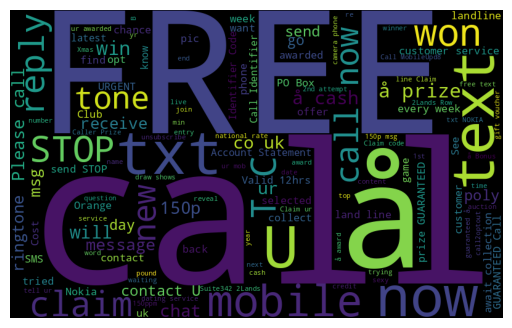

In [ ]:
# wordcloud is a image, show wordcloud image of spam mail on screen
# use matplotlib
plt.figure(figsize=(8,4))

# im.show() inbuild method for show image which define in matplotlib
plt.imshow(wc)

plt.axis("off")    #close the axis
plt.show()

creating wordcloud for not spam

In [ ]:
df[df["category"]=="not spam"]["Message"]

,Message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
6,Even my brother is not like to speak with me. ...
...,...
5565,Huh y lei...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [ ]:
msg = "".join(df[df["category"]=="not spam"]["Message"])

In [ ]:
msg

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...Ok lar... Joking wif u oni...U dun say so early hor... U c already then say...Nah I don\'t think he goes to usf, he lives around here thoughEven my brother is not like to speak with me. They treat me like aids patent.As per your request \'Melle Melle (Oru Minnaminunginte Nurungu Vettam)\' has been set as your callertune for all Callers. Press *9 to copy your friends CallertuneI\'m gonna be home soon and i don\'t want to talk about this stuff anymore tonight, k? I\'ve cried enough today.I\'ve been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.I HAVE A DATE ON SUNDAY WITH WILL!!Oh k...i\'m watching here:)Eh u remember how 2 spell his name... Yes i did. He v naughty make until i v wet.Fine if thatåÕs the way u feel. ThatåÕs the way its gota 

In [ ]:
# create object of WordCloud
# 800 px--> px means pixel --> smallest unit of graphic
wc = WordCloud(width = 800, height = 500, background_color = "black", min_font_size = 10)

# create a wordcloud of spam message
# use inbuild method generate() which define in WordCloud class
wc.generate(msg)

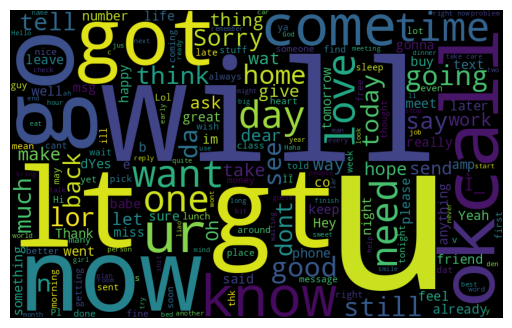

In [ ]:
# wordcloud is a image, show wordcloud image of spam mail on screen
# use matplotlib
plt.figure(figsize=(8,4))

# im.show() inbuild method for show image which define in matplotlib
plt.imshow(wc)

plt.axis("off")    #close the axis
plt.show()

# Text Preprocessing
1. NLU: Natural Language understanding

In [ ]:
from nltk.tokenize import word_tokenize                     # break given sentence into words
from nltk.corpus import stopwords                           # to remove stopwords
from nltk.stem import WordNetLemmatizer                     # lemmatization: similar type of word get group
from sklearn.feature_extraction.text import CountVectorizer # feature extract and covert into table

In [ ]:
# list of stopwords
stop = stopwords.words("english")

#stop is user define variable
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
# Create userdefine function for cleaning text/Preprocessing the text
def clean_text(msg):           # clean_text() user defined text
  msg = msg.lower()            # convert text into lower case
  tokens = word_tokenize(msg)  # apply word tokenizer
  # print(tokens)

  # Remove digit and special character from tokens list only old  alphabets only
  # use inbuild function isalpha() --> only alphabet
  # use list comprehension
  tokens = [w for w in tokens if w.isalpha()]
  # print(tokens)

  tokens = [w for w in tokens if w not in stop]   # Remove stopword, use list comprehension
  # print(tokens)

  # Apply lemmatization
  # create the object of WordNetLemmatizer class
  lemma = WordNetLemmatizer()
  lemma_token = [lemma.lemmatize(w, pos="v") for w in tokens]
  # print(lemma_token)

  lemma_token = " ".join(lemma_token)
  return lemma_token

In [ ]:
# txt = "Python is a interpreted language. Python @ is developed in 1991."
# txt = "Rohan wolf wolves rohan@gmail.com study histories studies feet foot He is Studying in 10 th standard"

# call function
# clean_text(txt)

In [ ]:
#a apply is a inbuild function
# input.apply(function_name)

df["Message"] = df["Message"].apply(clean_text)
df.head()

,category,Message
0,not spam,go jurong point crazy available bugis n great ...
1,not spam,ok lar joke wif u oni
2,spam,free entry wkly comp win fa cup final tkts may...
3,not spam,u dun say early hor u c already say
4,not spam,nah think go usf live around though


In [ ]:
# Apply LabelEncoder on otput cloumn category to change string value to numeric type data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["category"] = le.fit_transform(df["category"])
df.head()

,category,Message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joke wif u oni
2,1,free entry wkly comp win fa cup final tkts may...
3,0,u dun say early hor u c already say
4,0,nah think go usf live around though


In [ ]:
# select input and output
x = df["Message"]        # input
y = df["category"]       # output

In [ ]:
#train test split means spliting the data in train test 70% training and 30% testing

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.3, random_state=1)

In [ ]:
print(xtrain.shape, xtest.shape)
print(ytrain.shape, ytest.shape)

(3900,) (1672,)
(3900,) (1672,)


In [ ]:
xtrain

,Message
4393,baaaaaaaabe wake miss crave need
216,tire sleep well past nights
4471,receive mobile content enjoy
3889,double mins txts orange tariff latest motorola...
5030,hey inconvenient sis huh
...,...
905,hey charles sorry late reply
5192,oh oh den muz change plan liao go back yan jiu
3980,huh cant thk oredi many page
235,print oh lt gt come upstairs


In [ ]:
# Now once we have the clean text in hand, the next thing that we would like into vector/number
# Apply CountVectorizer: It convert object type data type into numeric type

#call inbuild class CountVector

from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# create the objcet of CountVectorizerclass
cv = CountVectorizer()

In [ ]:
xtrainCV = cv.fit_transform(xtrain) # 70% input xtrain
xtestCV = cv.transform(xtest)       # 30% input xtest

In [ ]:
xtrainCV

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 29663 stored elements and shape (3900, 5167)>

In [ ]:
xtestCV

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11578 stored elements and shape (1672, 5167)>

In [ ]:
#to show column name
cv.get_feature_names_out()

array(['aah', 'aaooooright', 'aathi', ..., 'åòit', 'åômorrow', 'ìï'],
      dtype=object)

In [ ]:
pd.DataFrame(xtrainCV.toarray(), columns = cv.get_feature_names_out())

,aah,aaooooright,aathi,ab,abbey,abeg,abel,abi,ability,abiola,...,zoe,zogtorius,zoom,zouk,zyada,åð,åòharry,åòit,åômorrow,ìï
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
pd.DataFrame(xtestCV.toarray(), columns = cv.get_feature_names_out())

,aah,aaooooright,aathi,ab,abbey,abeg,abel,abi,ability,abiola,...,zoe,zogtorius,zoom,zouk,zyada,åð,åòharry,åòit,åômorrow,ìï
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1667,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1668,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1669,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1670,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**1. Model- ML(DecisionTreeClassifier)**

In [ ]:
# Fit the data in ML algorithm
# we have given dataset in a classification dataset, here we use DecisionTreeClassifier Algorith
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Create the object of DecisionTreeClassifier class  with gini index
dtc = DecisionTreeClassifier()        #by default criterion = "gini"

In [ ]:
# train model with 70% training input and training output using fit method
dtc.fit(xtrainCV,ytrain)

DecisionTreeClassifier()

In [ ]:
#test the model with 30% data
ypred = dtc.predict(xtestCV)

In [ ]:
#print confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
cm = confusion_matrix(ytest, ypred)
ac = accuracy_score(ytest, ypred)
cr = classification_report(ytest, ypred)

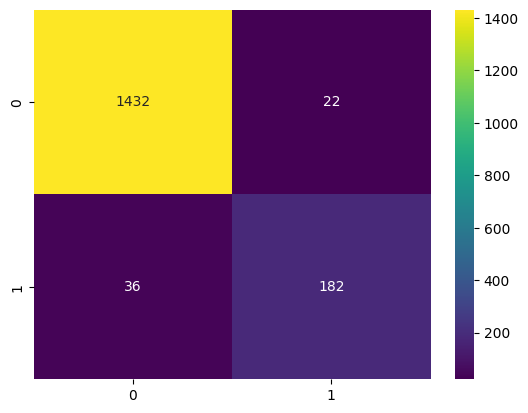

In [ ]:
sns.heatmap(cm,annot=True, fmt = "d", cmap ="viridis" )
plt.show()

In [ ]:
print(cm)
print(ac)
print(cr)

[[1432   22]
 [  36  182]]
0.965311004784689
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1454
           1       0.89      0.83      0.86       218

    accuracy                           0.97      1672
   macro avg       0.93      0.91      0.92      1672
weighted avg       0.96      0.97      0.96      1672



**2. Model - Neural Network**

In [ ]:
# perform model with the help of neutral network:
# use ANN : Artificial Neural network

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Compulsory in neural network, converts xtrainCV into toarray() since in ML it automatic convert into array but not in ANN
# same for xtestCV

xtrainCV1 = xtrainCV.toarray()
xtestCV1  = xtestCV.toarray()

In [ ]:
xtrainCV1.shape

(3900, 5167)

In [ ]:
xtestCV1.shape

(1672, 5167)

In [ ]:
# create the object of Sequential class
model = Sequential()
model.add(Dense(units=5168,activation ="relu", input_shape = (5167,))) # first hidden and input layer
model.add(Dense(units=1, activation="sigmoid"))                        # output layer

In [ ]:
# to show summary
model.summary()

#no. of parameters train in hidden layer = 5167 * 5168 + 5168 = 26,708,224
#no. of parameters train in output layer = 5168*1 + 1 = 5,169

# total parameter = 26,708,224 + 5,169 = 26,713,393

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5168)           │    26,708,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         5,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,713,393 (101.90 MB)

 Trainable params: 26,713,393 (101.90 MB)

 Non-trainable params: 0 (0.00 B)

sgd --> look only for momentum   
adam --> direction and mometum

adam --> adagrade and momentum (adagrade means focus on direction)(adam make process fast as compare to sdg)

In [ ]:
# compile the model

model.compile(optimizer="adam", loss = "binary_crossentropy", metrics=["accuracy"])

In [ ]:
# what is the weight and bias assign lst time in each layer
# use inbuild method get_weights() of sequential class
# weight = are all diff
# but bias is 0  initially

# model.get_weights()

In [ ]:
#     monitor="val_loss",           # Which metric to watch (usually validation loss).
#     min_delta=0.0001,             # Minimum change to count as an improvement.
#     patience=20,                  # How many epochs to wait before giving up.
#     verbose=1,                    # Show a message in the console when stopping.
#     mode="auto",                  # Automatically detects if the metric should go up or down.
#     baseline=None,                # A specific target value the model must reach.
#     restore_best_weights=False    # If True, keeps the 'best' weights instead of the 'last' ones.

```
monitor: The "sensor" watching for progress.
min_delta: The "tiny step" that qualifies as progress.
patience: The "limit" on how long to wait for a improvement.
verbose: The "talkative" mode to see what's happening.
mode: The "logic" (Is lower better or higher better?).
baseline: The "starting bar" the model has to clear.
restore_best_weights: The "rewind" button to go back to the best version.
```

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# create the object of EarlyStopping class and passing the following parameter
es = EarlyStopping(monitor="val_loss",                # THE SCORE: What the coach is watching.
                   min_delta=0.0001,                  # THE EFFORT: How much better the runner must get to count.
                   patience=20,                       # THE CHANCE: How many tries they get before the coach stops them.
                   verbose=1,                         # THE ANNOUNCEMENT: Does the coach shout when they stop?
                   mode="auto",                       # THE GOAL: Coach decides if "low" or "high" is better.
                   baseline=None,                     # THE TARGET: A minimum score they must reach first.
                   restore_best_weights=False)        # THE TROPHY: Do we keep the best run or the last run?

In [ ]:
#traain the model with 70% off data
TrainModel = model.fit(xtrainCV1,ytrain,epochs=5000, batch_size=100,
                       callbacks = es, validation_data=(xtestCV1,ytest))

Epoch 1/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 713ms/step - accuracy: 0.9292 - loss: 0.2162 - val_accuracy: 0.9815 - val_loss: 0.0856
Epoch 2/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 718ms/step - accuracy: 0.9915 - loss: 0.0254 - val_accuracy: 0.9827 - val_loss: 0.0758
Epoch 3/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 739ms/step - accuracy: 0.9972 - loss: 0.0085 - val_accuracy: 0.9809 - val_loss: 0.0868
Epoch 4/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 692ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9809 - val_loss: 0.0891
Epoch 5/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 663ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.9803 - val_loss: 0.0954
Epoch 6/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9803 - val_loss: 0.1009
Epoch 7/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 708ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9803 - val_loss: 0.1050
Epoch 8/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 694ms/step - accuracy: 1.0000 - loss: 8.95

In [ ]:
# test the model with 30% testing data
ypred = model.predict(xtestCV1).round(2)
ypred = np.where(ypred>=0.5,1,0)
ypred

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step


array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])

In [ ]:
cm = confusion_matrix(ytest, ypred)
ac = accuracy_score(ytest, ypred)
cr = classification_report(ytest, ypred)

In [ ]:
print(cm)
print(ac)
print(cr)

[[1450    4]
 [  32  186]]
0.9784688995215312
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1454
           1       0.98      0.85      0.91       218

    accuracy                           0.98      1672
   macro avg       0.98      0.93      0.95      1672
weighted avg       0.98      0.98      0.98      1672



In [ ]:
# The End

# **TF-IDF**

In [ ]:
# Apply TF-IDF Vectorizer: It convert object type data type into numeric type

#call inbuild class TfidfVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# create the object of TfidfVectorizer class
tfidf = TfidfVectorizer()

In [ ]:
xtrainTF = tfidf.fit_transform(xtrain) # 70% input xtrain
xtestTF = tfidf.transform(xtest)       # 30% input xtest

In [ ]:
#dataframe of train
pd.DataFrame(xtrainTF.toarray(), columns = tfidf.get_feature_names_out())

,aah,aaooooright,aathi,ab,abbey,abeg,abel,abi,ability,abiola,...,zoe,zogtorius,zoom,zouk,zyada,åð,åòharry,åòit,åômorrow,ìï
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3898,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#dataframe of test
pd.DataFrame(xtestTF.toarray(), columns = tfidf.get_feature_names_out())

,aah,aaooooright,aathi,ab,abbey,abeg,abel,abi,ability,abiola,...,zoe,zogtorius,zoom,zouk,zyada,åð,åòharry,åòit,åômorrow,ìï
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1670,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**1. Model- ML(DecisionTreeClassifier)**

In [ ]:
# Fit the data in ML algorithm
# we have given dataset in a classification dataset, here we use DecisionTreeClassifier Algorith
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Create the object of DecisionTreeClassifier class  with gini index
dtc = DecisionTreeClassifier()        #by default criterion = "gini"

In [ ]:
# train model with 70% training input and training output using fit method
dtc.fit(xtrainTF,ytrain)

DecisionTreeClassifier()

In [ ]:
#test the model with 30% data
ypred = dtc.predict(xtestTF)

In [ ]:
#print confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
cm = confusion_matrix(ytest, ypred)
ac = accuracy_score(ytest, ypred)
cr = classification_report(ytest, ypred)

In [ ]:
print(cm)
print("\n",ac,"\n")
print(cr)

[[1418   36]
 [  47  171]]

 0.9503588516746412 

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1454
           1       0.83      0.78      0.80       218

    accuracy                           0.95      1672
   macro avg       0.90      0.88      0.89      1672
weighted avg       0.95      0.95      0.95      1672



**2. Model - Neural Network**

In [ ]:
# perform model with the help of neutral network:
# use ANN : Artificial Neural network

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Compulsory in neural network, converts xtrainCV into toarray() since in ML it automatic convert into array but not in ANN
# same for xtestCV

xtrainTF1 = xtrainTF.toarray()
xtestTF1  = xtestTF.toarray()

In [ ]:
print(xtrainTF1.shape,xtestTF1.shape)

(3900, 5167) (1672, 5167)


In [ ]:
# create the object of Sequential class
model = Sequential()
model.add(Dense(units=5168,activation ="relu", input_shape = (5167,))) # first hidden and input layer
model.add(Dense(units=1, activation="sigmoid"))                        # output layer

In [ ]:
# to show summary
model.summary()

#no. of parameters train in hidden layer = 5167 * 5168 + 5168 = 26,708,224
#no. of parameters train in output layer = 5168*1 + 1 = 5,169

# total parameter = 26,708,224 + 5,169 = 26,713,393

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 5168)           │    26,708,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         5,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,713,393 (101.90 MB)

 Trainable params: 26,713,393 (101.90 MB)

 Non-trainable params: 0 (0.00 B)

sgd --> look only for momentum   
adam --> direction and mometum

adam --> adagrade and momentum (adagrade means focus on direction)(adam make process fast as compare to sdg)

In [ ]:
# compile the model

model.compile(optimizer="adam", loss = "binary_crossentropy", metrics=["accuracy"])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# create the object of EarlyStopping class and passing the following parameter
es = EarlyStopping(monitor="val_loss",                # THE SCORE: What the coach is watching.
                   min_delta=0.0001,                  # THE EFFORT: How much better the runner must get to count.
                   patience=20,                       # THE CHANCE: How many tries they get before the coach stops them.
                   verbose=1,                         # THE ANNOUNCEMENT: Does the coach shout when they stop?
                   mode="auto",                       # THE GOAL: Coach decides if "low" or "high" is better.
                   baseline=None,                     # THE TARGET: A minimum score they must reach first.
                   restore_best_weights=False)        # THE TROPHY: Do we keep the best run or the last run?

In [ ]:
#traain the model with 70% off data
TrainModel = model.fit(xtrainTF1,ytrain,epochs=5000, batch_size=100,
                       callbacks = es, validation_data=(xtestTF1,ytest))

Epoch 1/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 956ms/step - accuracy: 0.8844 - loss: 0.3009 - val_accuracy: 0.9641 - val_loss: 0.1291
Epoch 2/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 32s 740ms/step - accuracy: 0.9841 - loss: 0.0586 - val_accuracy: 0.9809 - val_loss: 0.0744
Epoch 3/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 701ms/step - accuracy: 0.9949 - loss: 0.0167 - val_accuracy: 0.9821 - val_loss: 0.0709
Epoch 4/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 662ms/step - accuracy: 0.9990 - loss: 0.0067 - val_accuracy: 0.9809 - val_loss: 0.0778
Epoch 5/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 731ms/step - accuracy: 0.9997 - loss: 0.0036 - val_accuracy: 0.9815 - val_loss: 0.0795
Epoch 6/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 730ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9815 - val_loss: 0.0821
Epoch 7/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 30s 768ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9815 - val_loss: 0.0848
Epoch 8/5000
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 751ms/step - accuracy: 1.0000 - loss: 0

In [ ]:
# test the model with 30% testing data
ypred = model.predict(xtestCV1).round(2)
ypred = np.where(ypred>=0.5,1,0)
ypred

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step


array([[0],
       [0],
       [1],
       ...,
       [1],
       [0],
       [0]])

In [ ]:
cm = confusion_matrix(ytest, ypred)
ac = accuracy_score(ytest, ypred)
cr = classification_report(ytest, ypred)

In [ ]:
print(cm)
print(ac)
print(cr)

[[1435   19]
 [  15  203]]
0.9796650717703349
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1454
           1       0.91      0.93      0.92       218

    accuracy                           0.98      1672
   macro avg       0.95      0.96      0.96      1672
weighted avg       0.98      0.98      0.98      1672

